<a href="https://colab.research.google.com/github/zixian0821-zoe/stochastic_search_and_optimization/blob/main/hw6_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IC=A  c=  100  n=   10  MSE_total UW=2.736974e+01  W=1.199857e+00
IC=A  c=  100  n=   50  MSE_total UW=4.388101e+00  W=1.673958e-01
IC=A  c=  100  n=  100  MSE_total UW=1.979075e+00  W=7.348966e-02
IC=A  c=  100  n=  500  MSE_total UW=4.164599e-01  W=1.867162e-02
IC=A  c=  100  n= 1000  MSE_total UW=2.014313e-01  W=8.608140e-03
IC=A  c=  100  n= 3000  MSE_total UW=6.792399e-02  W=2.724395e-03
IC=A  c= 1000  n=   10  MSE_total UW=2.683765e+02  W=1.197165e+00
IC=A  c= 1000  n=   50  MSE_total UW=4.333100e+01  W=1.681073e-01
IC=A  c= 1000  n=  100  MSE_total UW=1.961409e+01  W=7.405973e-02
IC=A  c= 1000  n=  500  MSE_total UW=4.095146e+00  W=1.875271e-02
IC=A  c= 1000  n= 1000  MSE_total UW=2.033178e+00  W=8.846167e-03
IC=A  c= 1000  n= 3000  MSE_total UW=6.740727e-01  W=2.753519e-03
IC=B  c=  100  n=   10  MSE_total UW=1.366654e+01  W=1.314410e+00
IC=B  c=  100  n=   50  MSE_total UW=3.748177e+00  W=2.142485e-01
IC=B  c=  100  n=  100  MSE_total UW=1.816817e+00  W=8.094659e-02
IC=B  c=  

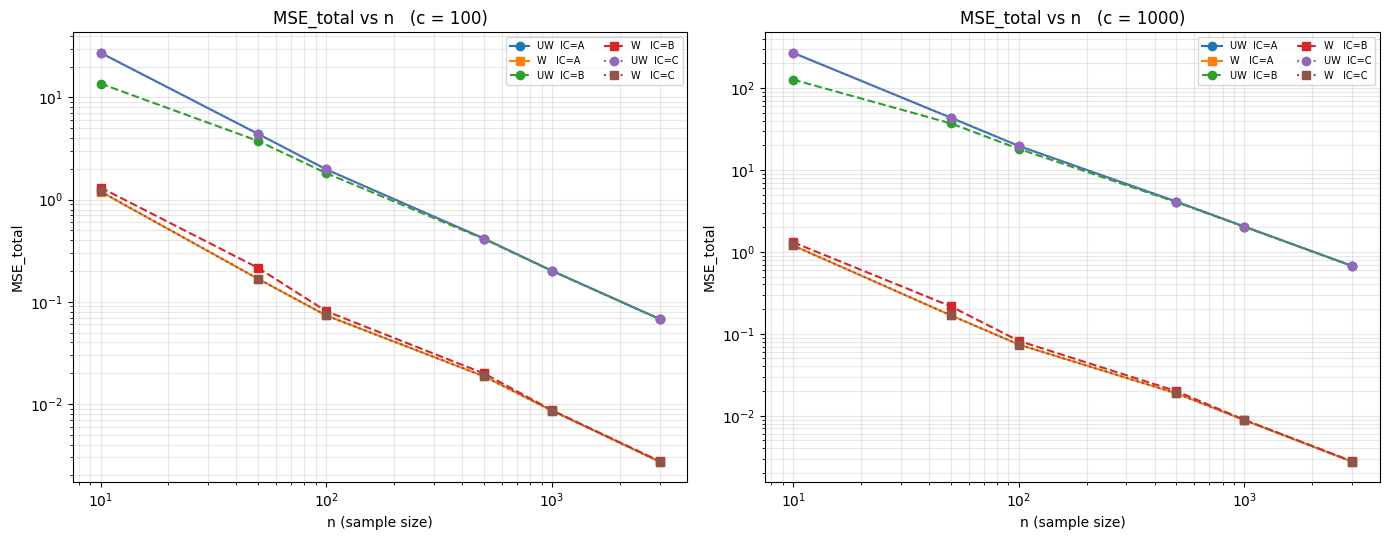

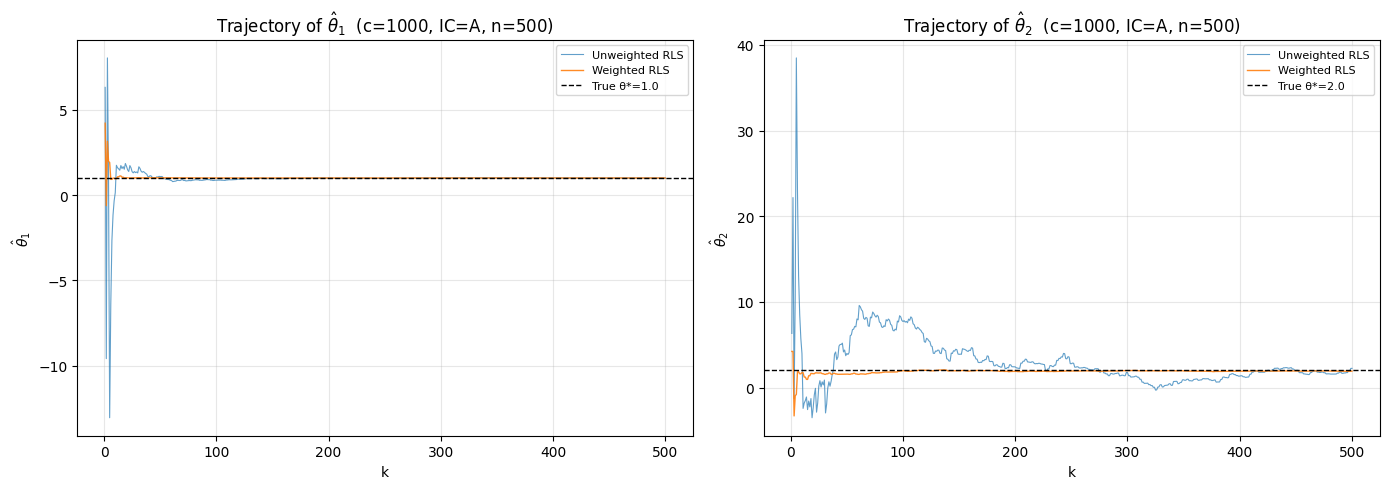

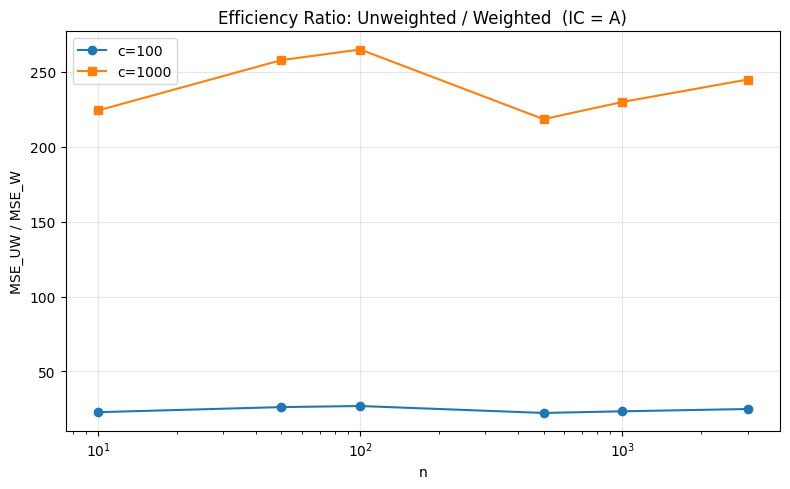


*** All done. ***


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_data(n, theta_star, c, rng):
    p = len(theta_star)
    H = np.zeros((n, p))
    sigma2 = np.zeros(n)
    z = np.zeros(n)
    for k_idx in range(n):
        k = k_idx + 1
        H[k_idx] = [k, 1.0]
        sigma2[k_idx] = 1.0 if (k % 2 == 0) else c
        v_k = rng.normal(0.0, np.sqrt(sigma2[k_idx]))
        z[k_idx] = H[k_idx] @ theta_star + v_k
    return H, z, sigma2

def rls_unweighted(H, z, theta0, P0):
    n, p = H.shape
    theta = theta0.copy()
    P = P0.copy()
    traj = np.zeros((n, p))
    for k in range(n):
        h = H[k].reshape(-1, 1)
        Ph = P @ h
        denom = 1.0 + (h.T @ Ph).item()
        P = P - (Ph @ Ph.T) / denom
        innov = z[k] - (h.T @ theta.reshape(-1, 1)).item()
        theta = theta + (P @ h).flatten() * innov
        traj[k] = theta
    return traj

def rls_weighted(H, z, sigma2, theta0, P0):
    n, p = H.shape
    theta = theta0.copy()
    P = P0.copy()
    traj = np.zeros((n, p))
    for k in range(n):
        h = H[k].reshape(-1, 1)
        s2 = sigma2[k]
        Ph = P @ h
        denom = s2 + (h.T @ Ph).item()
        P = P - (Ph @ Ph.T) / denom
        innov = z[k] - (h.T @ theta.reshape(-1, 1)).item()
        theta = theta + (P @ h).flatten() * innov / s2
        traj[k] = theta
    return traj

def run_mc(n, theta_star, c, theta0, P0, M=200, seed=42):
    p = len(theta_star)
    sq_err_uw = np.zeros(p)
    sq_err_w = np.zeros(p)
    traj_uw_rep = None
    traj_w_rep = None
    rng = np.random.default_rng(seed)

    for m in range(M):
        H, z, sigma2 = simulate_data(n, theta_star, c, rng)
        traj_uw = rls_unweighted(H, z, theta0.copy(), P0.copy())
        traj_w = rls_weighted(H, z, sigma2, theta0.copy(), P0.copy())
        err_uw = traj_uw[-1] - theta_star
        err_w = traj_w[-1] - theta_star
        sq_err_uw += err_uw**2
        sq_err_w += err_w**2
        if m == 0:
            traj_uw_rep = traj_uw.copy()
            traj_w_rep = traj_w.copy()

    mse_uw = sq_err_uw / M
    mse_w = sq_err_w / M
    return {
        'mse_uw': mse_uw,
        'mse_w': mse_w,
        'mse_total_uw': mse_uw.sum(),
        'mse_total_w': mse_w.sum(),
        'traj_uw': traj_uw_rep,
        'traj_w': traj_w_rep,
    }

theta_star = np.array([1.0, 2.0])
ns = [10, 50, 100, 500, 1000, 3000]
cs = [100, 1000]
M = 200

init_conds = {
    'A': (np.array([0.0, 0.0]), 1e3 * np.eye(2)),
    'B': (np.array([0.0, 0.0]), 1.0 * np.eye(2)),
    'C': (np.array([10.0, -10.0]), 1e3 * np.eye(2)),
}

results = {}

for ic_label, (theta0, P0) in init_conds.items():
    for c in cs:
        for n in ns:
            res = run_mc(n, theta_star, c, theta0, P0, M=M, seed=42)
            results[(ic_label, c, n)] = res
            print(
                f"IC={ic_label}  c={c:5d}  n={n:5d}  "
                f"MSE_total UW={res['mse_total_uw']:.6e}  "
                f"W={res['mse_total_w']:.6e}"
            )

print("\n" + "=" * 110)
print(
    f"{'IC':>3} {'c':>5} {'n':>5} | {'MSE_θ1(UW)':>12} {'MSE_θ2(UW)':>12} {'MSE_tot(UW)':>12} | "
    f"{'MSE_θ1(W)':>12} {'MSE_θ2(W)':>12} {'MSE_tot(W)':>12}"
)
print("=" * 110)

for ic_label in ['A', 'B', 'C']:
    for c in cs:
        for n in ns:
            r = results[(ic_label, c, n)]
            print(
                f"{ic_label:>3} {c:>5} {n:>5} | "
                f"{r['mse_uw'][0]:>12.6e} {r['mse_uw'][1]:>12.6e} {r['mse_total_uw']:>12.6e} | "
                f"{r['mse_w'][0]:>12.6e} {r['mse_w'][1]:>12.6e} {r['mse_total_w']:>12.6e}"
            )
        print("-" * 110)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
for idx, c in enumerate(cs):
    ax = axes[idx]
    for ic_label, ls in [('A', '-'), ('B', '--'), ('C', ':')]:
        mse_uw_list = [results[(ic_label, c, n)]['mse_total_uw'] for n in ns]
        mse_w_list = [results[(ic_label, c, n)]['mse_total_w'] for n in ns]
        ax.plot(ns, mse_uw_list, marker='o', ls=ls, label=f'UW  IC={ic_label}')
        ax.plot(ns, mse_w_list, marker='s', ls=ls, label=f'W   IC={ic_label}')
    ax.set_xlabel('n (sample size)')
    ax.set_ylabel('MSE_total')
    ax.set_title(f'MSE_total vs n   (c = {c})')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

pick = results[('A', 1000, 500)]
traj_uw = pick['traj_uw']
traj_w = pick['traj_w']
ks = np.arange(1, 501)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for j, comp_name in enumerate([r'$\hat{\theta}_1$', r'$\hat{\theta}_2$']):
    ax = axes[j]
    ax.plot(ks, traj_uw[:, j], alpha=0.7, lw=0.8, label='Unweighted RLS')
    ax.plot(ks, traj_w[:, j], alpha=0.9, lw=1.0, label='Weighted RLS')
    ax.axhline(theta_star[j], color='k', ls='--', lw=1, label=f'True θ*={theta_star[j]}')
    ax.set_xlabel('k')
    ax.set_ylabel(comp_name)
    ax.set_title(f'Trajectory of {comp_name}  (c=1000, IC=A, n=500)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for c, marker in [(100, 'o'), (1000, 's')]:
    ratios = [results[('A', c, n)]['mse_total_uw'] / results[('A', c, n)]['mse_total_w'] for n in ns]
    ax.plot(ns, ratios, marker=marker, label=f'c={c}')
ax.set_xlabel('n')
ax.set_ylabel('MSE_UW / MSE_W')
ax.set_title('Efficiency Ratio: Unweighted / Weighted  (IC = A)')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n*** All done. ***")

In [6]:
import numpy as np
import pandas as pd
import os
from google.colab import drive

drive.mount("/content/drive")

def find_latest_reeddata_xlsx(root="/content/drive"):
    cands = []
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            fl = f.lower()
            if ("reeddata" in fl) and fl.endswith(".xlsx"):
                cands.append(os.path.join(dirpath, f))
    return max(cands, key=os.path.getmtime) if cands else None

def load_data_325(xlsx_path):
    df = pd.read_excel(xlsx_path, header=None)
    raw = df.iloc[2:162, 0:7].astype(float).to_numpy()
    z = raw[:, 0]
    X_raw = raw[:, 1:7]
    return z, X_raw

def batch_ols(H, z):
    return np.linalg.lstsq(H, z, rcond=None)[0]

def rls(H, z, theta0, P0):
    n, p = H.shape
    theta = theta0.copy()
    P = P0.copy()
    for k in range(n):
        h = H[k].reshape(-1, 1)
        Ph = P @ h
        denom = 1.0 + (h.T @ Ph).item()
        P = P - (Ph @ Ph.T) / denom
        innov = z[k] - (h.T @ theta.reshape(-1, 1)).item()
        theta = theta + (P @ h).flatten() * innov
    return theta

xlsx_path = find_latest_reeddata_xlsx("/content/drive")
if xlsx_path is None:
    raise FileNotFoundError("No *reeddata*.xlsx found under /content/drive")

z, X_raw = load_data_325(xlsx_path)

H_325 = np.column_stack([np.ones(len(z)), X_raw])

theta_batch_325 = batch_ols(H_325, z)
theta_rls_325 = rls(H_325, z, np.zeros(H_325.shape[1]), np.eye(H_325.shape[1]))

df_325 = pd.DataFrame(
    {"batch": theta_batch_325, "rls": theta_rls_325},
    index=["theta0", "theta1", "theta2", "theta3", "theta4", "theta5", "theta6"]
)

df_325

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,batch,rls
theta0,-0.156246,-0.079093
theta1,0.102087,0.100643
theta2,0.055032,0.045762
theta3,0.175002,0.170720
theta4,0.044352,0.042969
theta5,0.055559,0.055697
theta6,0.579315,0.540227


In [7]:
import numpy as np

def grad_L(theta):
    t1, t2 = theta
    return np.array([4*t1**3 + 2*t1 + t2,
                     t1 + 2*t2])

def L(theta):
    t1, t2 = theta
    return t1**4 + t1**2 + t1*t2 + t2**2

def run_one(seed, sigma, mode, K=1000):
    rng = np.random.RandomState(seed)
    theta = np.array([1.0, 1.0])
    for k in range(K):
        if mode == 1:
            a_k = 0.1 / (k + 1)
        else:
            a_k = 0.1 / (k + 1)**0.501
        e_k = rng.normal(0, sigma, size=2)
        theta = theta - a_k * (grad_L(theta) + e_k)
    return L(theta)

def run_mc(sigma, mode, R=200, K=1000):
    losses = np.array([run_one(seed=i, sigma=sigma, mode=mode, K=K) for i in range(R)])
    return losses.mean(), losses.std()

if __name__ == "__main__":
    print(f"{'sigma':<8} {'gain sequence':<28} {'mean L':<14} {'std L':<14}")
    print("-" * 64)
    for sigma in [0.1, 1.0]:
        for mode, label in [(1, "a_k = 0.1/(k+1)"),
                            (2, "a_k = 0.1/(k+1)^0.501")]:
            m, s = run_mc(sigma, mode)
            print(f"{sigma:<8} {label:<28} {m:<14.6e} {s:<14.6e}")

sigma    gain sequence                mean L         std L         
----------------------------------------------------------------
0.1      a_k = 0.1/(k+1)              2.546131e-02   1.275012e-03  
0.1      a_k = 0.1/(k+1)^0.501        1.433003e-05   1.498671e-05  
1.0      a_k = 0.1/(k+1)              2.843720e-02   1.325213e-02  
1.0      a_k = 0.1/(k+1)^0.501        1.406390e-03   1.515194e-03  
